# MILESTONE 1

In [35]:
# Import statements 
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask


In [36]:
# Model run timestamp (October 12, 2021)
run = pd.Timestamp("2021-10-12-00")

In [37]:
# Output the timestamp
run

Timestamp('2021-10-12 00:00:00')

In [42]:
# Created Herbie objects for HRRR saved in Data collection
H = FastHerbie([run], model="hrrr", fxx=np.arange(0,49,1).tolist(), save_dir='meteo473/sp26_groupwork/473_sp26_group4/NewVariableDownloads', overwrite=True)

In [79]:
# Herbie inventory to search strings to match multiple parameters at once
# List of parameters: Temperature - TMP, Relative Humidity - RH, Total Cloud Cover - TCDC, Lightning - LTNG, Precipitation Rate - PRATE
H.inventory("(:TMP:2 m|:CAPE:surface:|:TCDC:entire|:CIN:surface:|:UGRD:10 m above|:VGRD:10 m above|:DPT:2 m above)")


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,71,35684897,36866497.0,35684897-36866497,2021-10-12,2021-10-12,TMP,2 m above ground,anl,:TMP:2 m above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,74,39403528,40565712.0,39403528-40565712,2021-10-12,2021-10-12,DPT,2 m above ground,anl,:DPT:2 m above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,77,42710659,45092273.0,42710659-45092273,2021-10-12,2021-10-12,UGRD,10 m above ground,anl,:UGRD:10 m above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,78,45092274,47473888.0,45092274-47473888,2021-10-12,2021-10-12,VGRD,10 m above ground,anl,:VGRD:10 m above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,105,62089377,62663117.0,62089377-62663117,2021-10-12,2021-10-12,CAPE,surface,anl,:CAPE:surface:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
...,...,...,...,...,...,...,...,...,...,...,...
338,77,55628082,58009696.0,55628082-58009696,2021-10-12,2021-10-14,UGRD,10 m above ground,48 hour fcst,:UGRD:10 m above ground:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
339,78,58009697,60391311.0,58009697-60391311,2021-10-12,2021-10-14,VGRD,10 m above ground,48 hour fcst,:VGRD:10 m above ground:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
340,108,80418071,81036217.0,80418071-81036217,2021-10-12,2021-10-14,CAPE,surface,48 hour fcst,:CAPE:surface:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
341,109,81036218,81808935.0,81036218-81808935,2021-10-12,2021-10-14,CIN,surface,48 hour fcst,:CIN:surface:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [2]:
# Import Statements
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the saved HRRR NetCDF file (downloaded in a separate notebook)
ds = xr.open_dataset('incident1hrrr.nc')

# Sort by valid time to ensure proper chronological order
ds = ds.sortby('valid_time')

# Preview dataset structure
ds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-30T16:56 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
# Choose one time index (you can change this later)
fcst = ds.isel(valid_time=24)

# Extract initialization and valid times
init_time = pd.to_datetime(ds.time.values)
valid_time = pd.to_datetime(fcst.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 10 2021
Valid Time: 00Z Oct 11 2021


In [4]:
# CONUS Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)

    return fig, ax

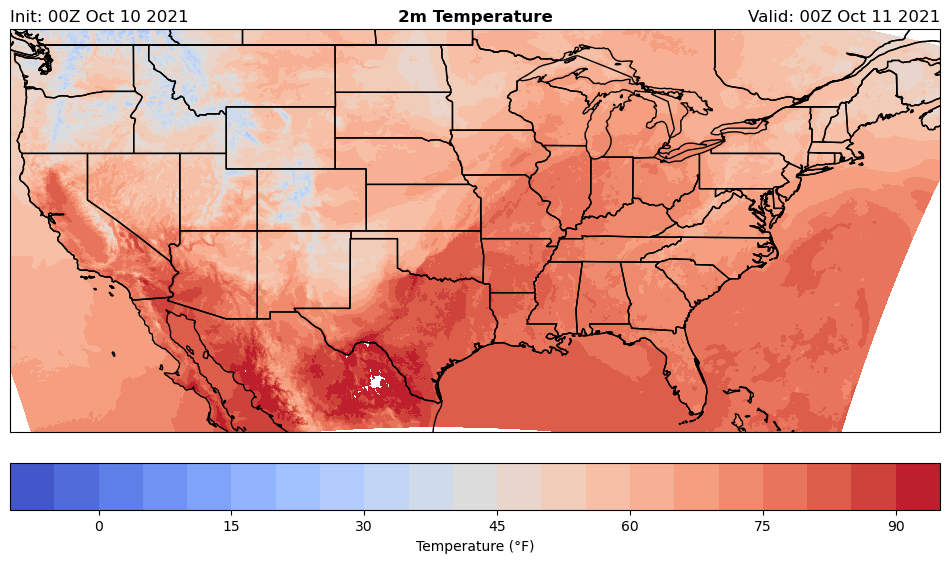

In [5]:
fig, ax = conus_map()

temp = (fcst['t2m'] - 273.15) * 9/5 + 32

cf = ax.contourf(ds.longitude, ds.latitude, temp,
levels = np.arange(-10, 100, 5), cmap='coolwarm',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Temperature (°F)')

plt.title("2m Temperature", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

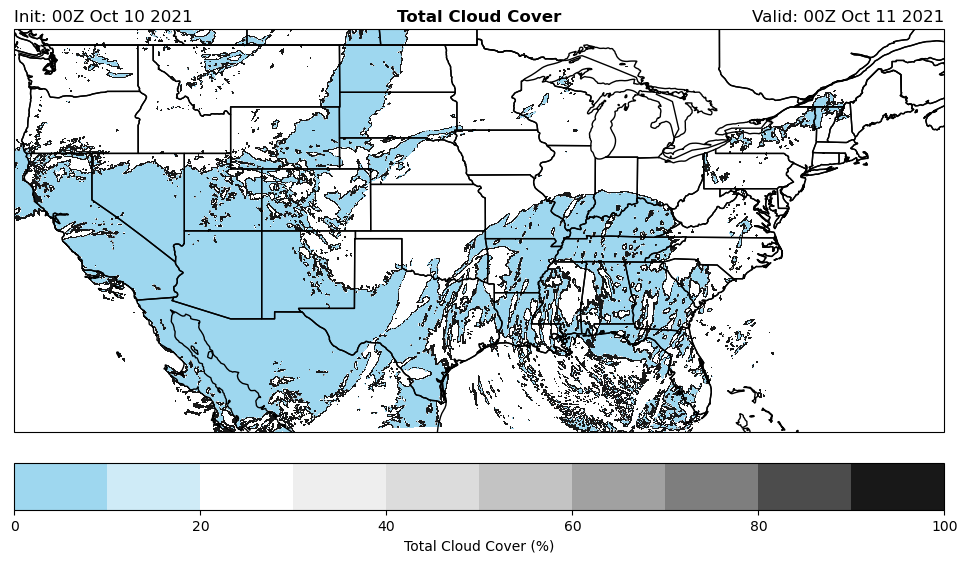

In [6]:
from matplotlib.colors import LinearSegmentedColormap

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)
fig, ax = conus_map()

cloud = fcst['tcc'] * 100  # convert to %

cf = ax.contourf(ds.longitude, ds.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')

plt.title("Total Cloud Cover", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

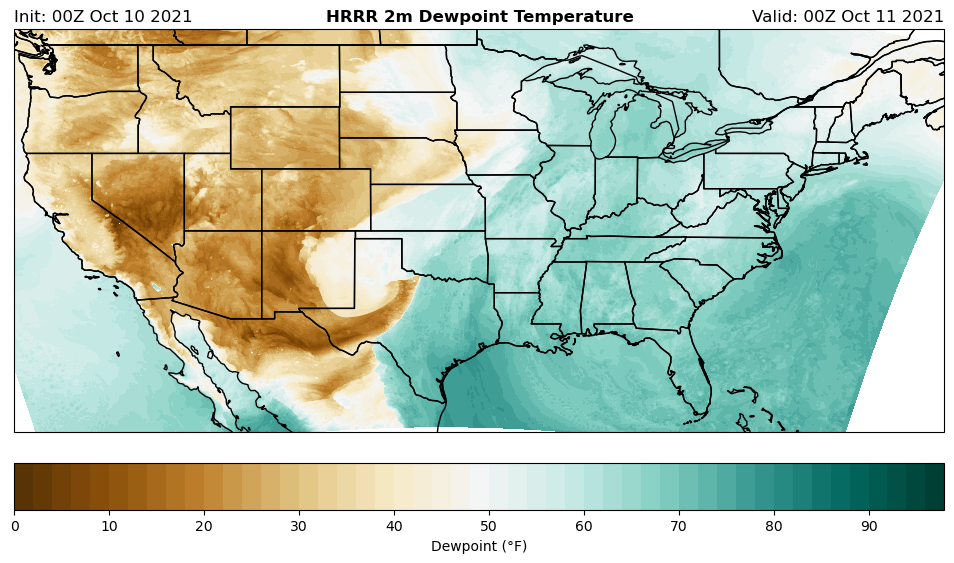

In [7]:
fig, ax = conus_map()

# Convert dewpoint from K → °F
dewpt = (fcst['d2m'] - 273.15) * 9/5 + 32

cf = ax.contourf(ds.longitude, ds.latitude, dewpt,
                 levels=np.arange(0, 100, 2),
                 cmap='BrBG',   # good for moisture
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Dewpoint (°F)')

plt.title("HRRR 2m Dewpoint Temperature", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

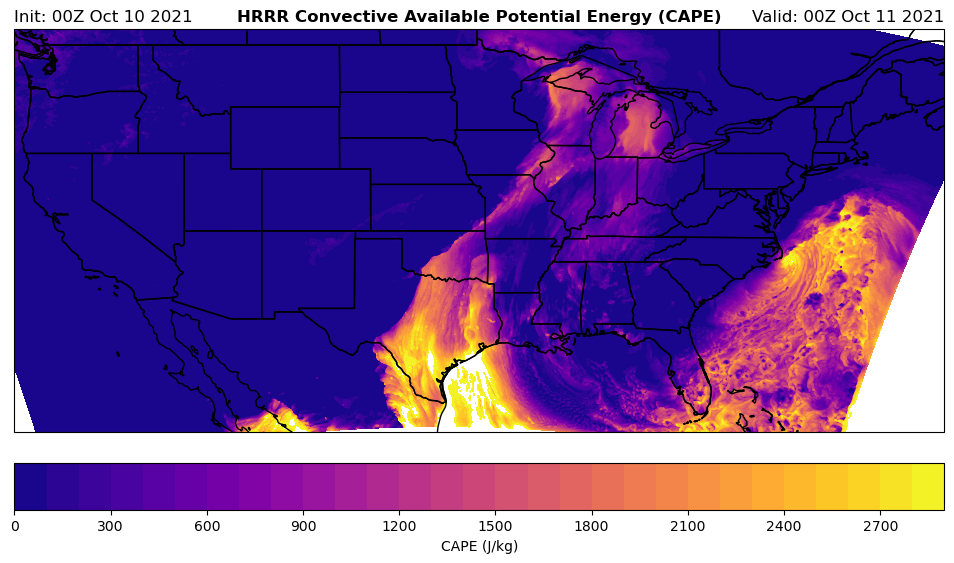

In [8]:
fig, ax = conus_map()

cape = fcst['cape']

cf = ax.contourf(ds.longitude, ds.latitude, cape,
                 levels=np.arange(0, 3000, 100),
                 cmap='plasma',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('CAPE (J/kg)')

plt.title("HRRR Convective Available Potential Energy (CAPE)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

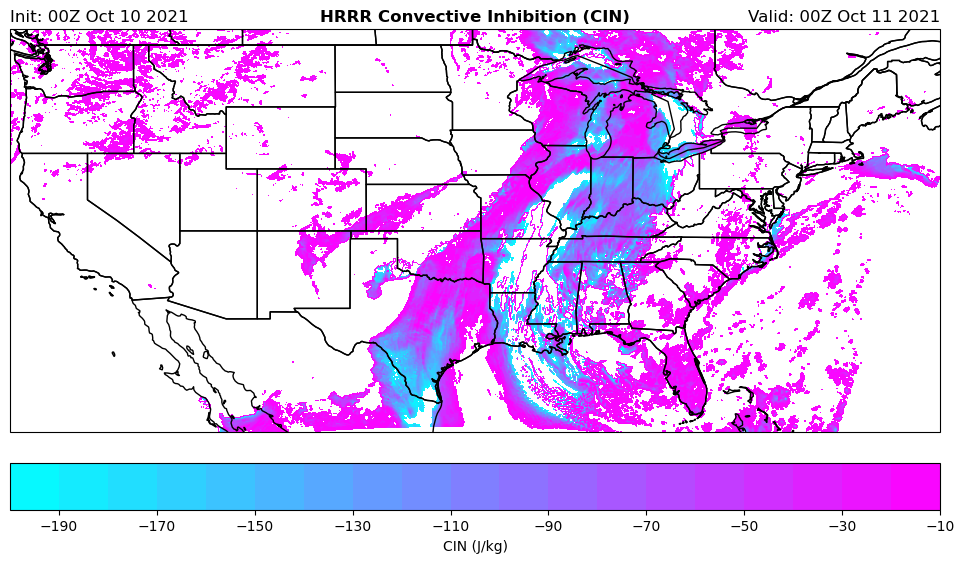

In [9]:
fig, ax = conus_map()

cin = fcst['cin']

cf = ax.contourf(ds.longitude, ds.latitude, cin,
                 levels=np.arange(-200, 0, 10),
                 cmap='cool',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('CIN (J/kg)')

plt.title("HRRR Convective Inhibition (CIN)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

# Milestone 2

In [17]:
# Imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units

In [18]:
# Load Data
ds = xr.open_dataset('MergedNull')
ds = ds.sortby('valid_time')

ds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-13 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T19:04 GRIB to CDM+CF via cfgrib-0.9.1...

In [19]:
# Choose one time index (you can change this later)
fcst = ds.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds.time.values)
valid_time = pd.to_datetime(fcst.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 13 2021
Valid Time: 00Z Oct 15 2021


In [20]:
# CONUS Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)

    return fig, ax

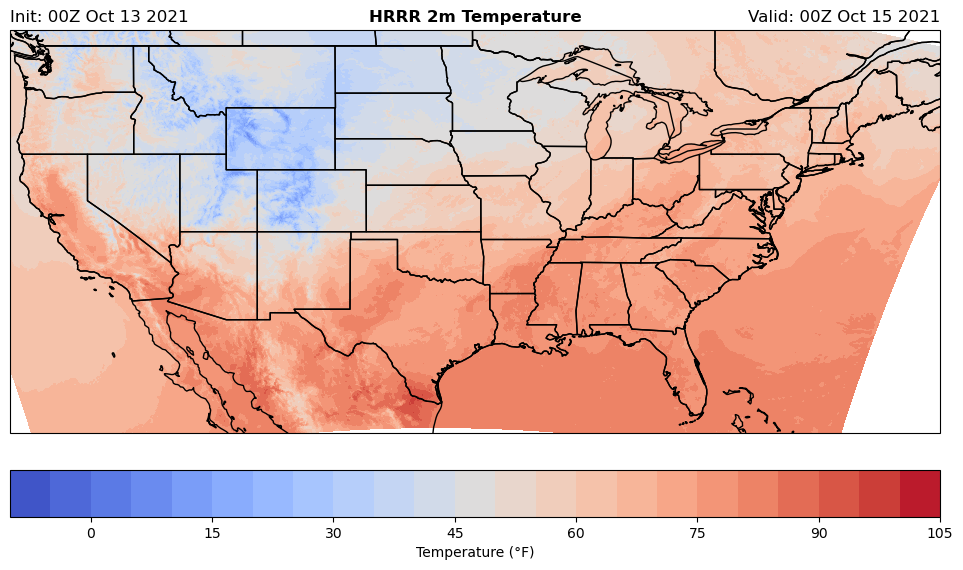

In [21]:
fig, ax = conus_map()

temp = (fcst['t2m'] - 273.15) * 9/5 + 32

cf = ax.contourf(ds.longitude, ds.latitude, temp,
                 levels=np.arange(-10, 110, 5),
                 cmap='coolwarm',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.06)
cbar.set_label('Temperature (°F)')

plt.title("HRRR 2m Temperature", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

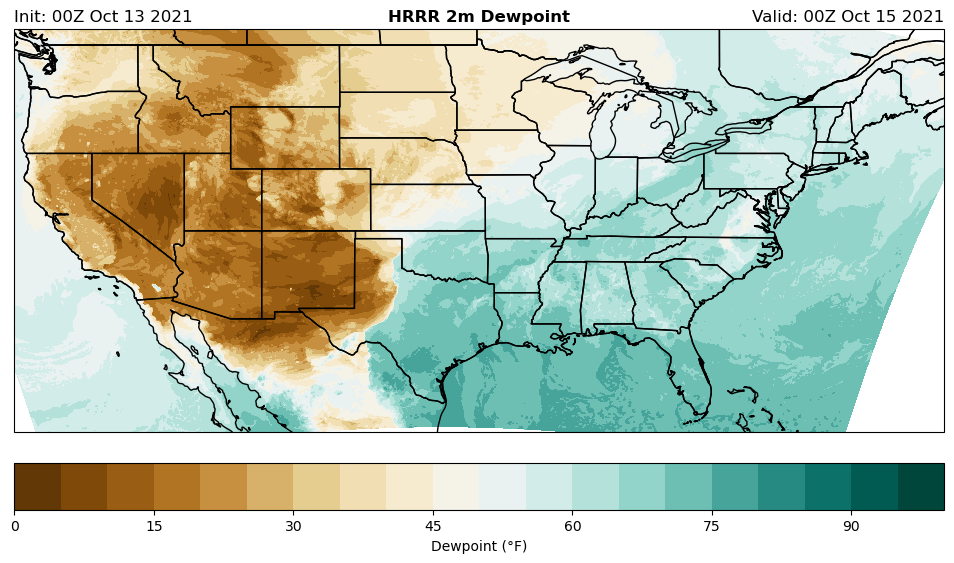

In [22]:
fig, ax = conus_map()

dew = (fcst['d2m'] - 273.15) * 9/5 + 32

cf = ax.contourf(ds.longitude, ds.latitude, dew,
                 levels=np.arange(0, 105, 5),
                 cmap='BrBG',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Dewpoint (°F)')

plt.title("HRRR 2m Dewpoint", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

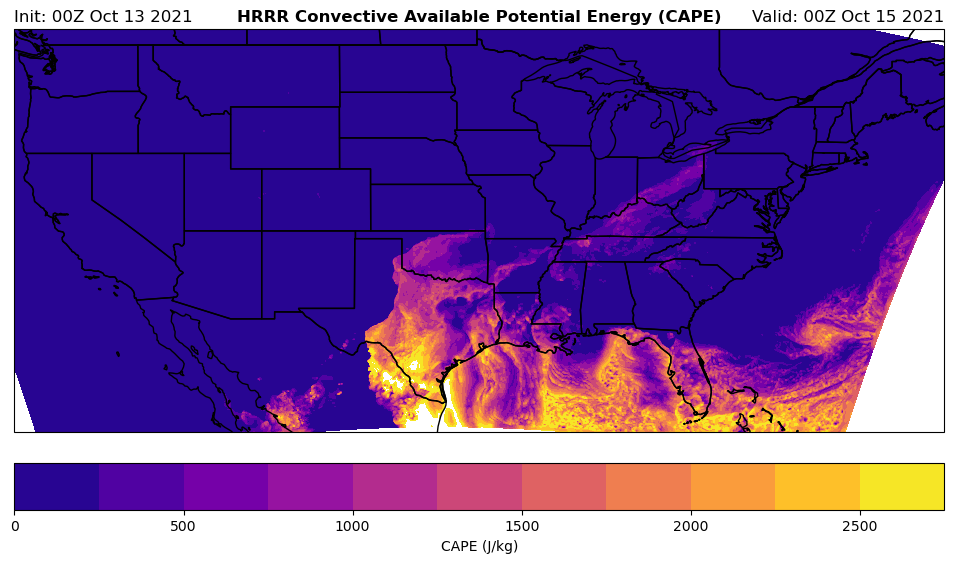

In [23]:
fig, ax = conus_map()

cape = fcst['cape']

cf = ax.contourf(ds.longitude, ds.latitude, cape,
                 levels=np.arange(0, 3000, 250),
                 cmap='plasma',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('CAPE (J/kg)')

plt.title("HRRR Convective Available Potential Energy (CAPE)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

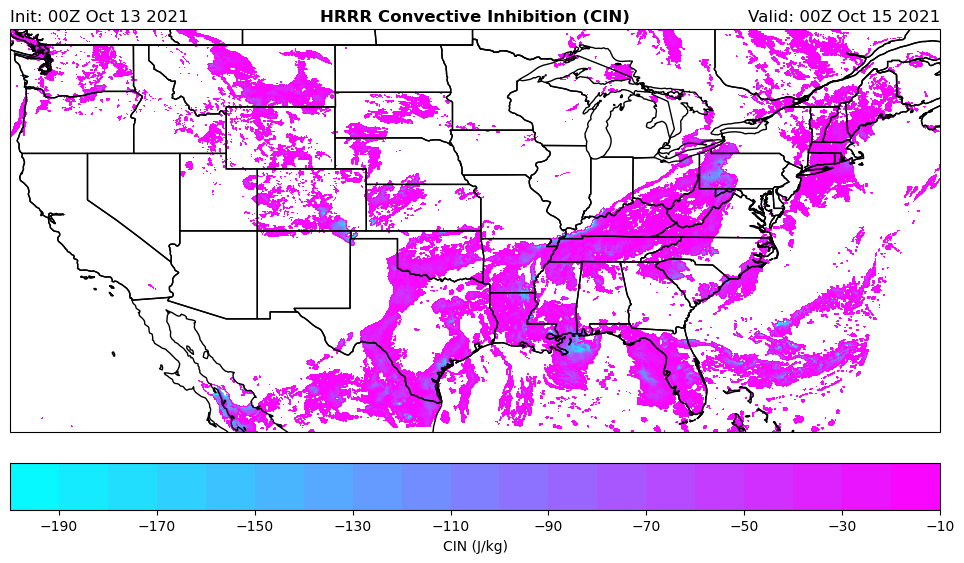

In [24]:
fig, ax = conus_map()

cin = fcst['cin']

cf = ax.contourf(ds.longitude, ds.latitude, cin,
                 levels=np.arange(-200, 0, 10),
                 cmap='cool',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('CIN (J/kg)')

plt.title("HRRR Convective Inhibition (CIN)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

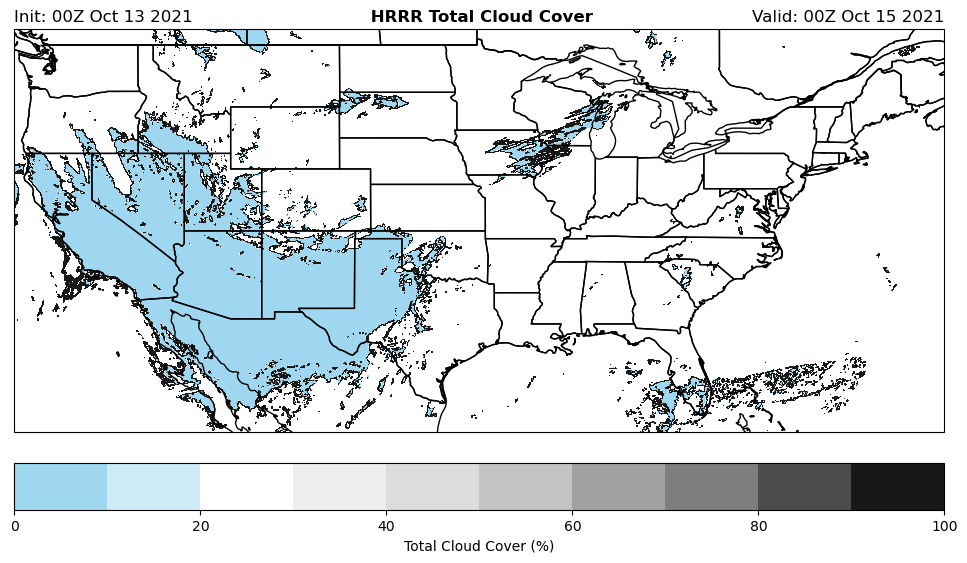

In [25]:
from matplotlib.colors import LinearSegmentedColormap

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)
fig, ax = conus_map()

cloud = fcst['tcc'] * 100  # convert to %

cf = ax.contourf(ds.longitude, ds.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')

plt.title(" HRRR Total Cloud Cover", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

In [26]:
u10 = fcst['u10']
v10 = fcst['v10']

wind_speed = np.sqrt(u10**2 + v10**2)

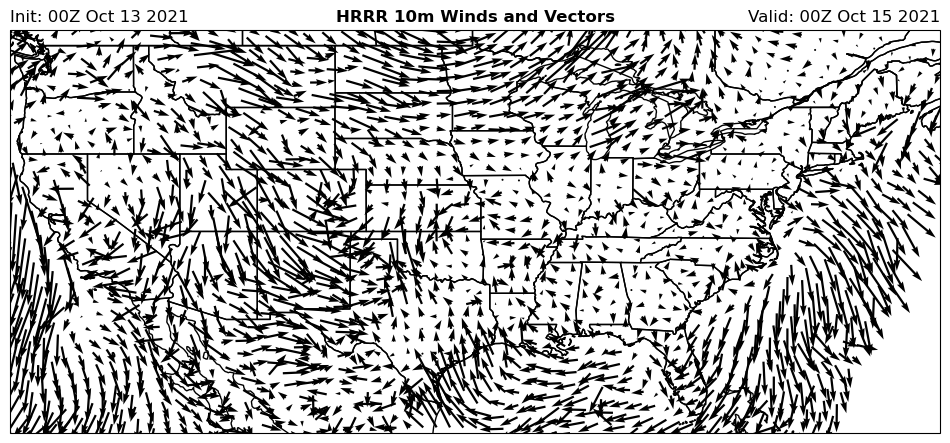

In [27]:
fig, ax = conus_map()

skip = 30

ax.quiver(ds.longitude[::skip, ::skip],
          ds.latitude[::skip, ::skip],
          u10[::skip, ::skip],
          v10[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

plt.title("HRRR 10m Winds and Vectors", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

In [28]:
# Imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units

In [29]:
import metpy.calc as mpcalc
from metpy.calc import lat_lon_grid_deltas
import metpy.units as units
import numpy as np

# Convert temperatures to Fahrenheit
temp_f = (fcst['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst['d2m'] - 273.15) * 9/5 + 32

cape = fcst['cape']
cin = fcst['cin']
cloud = fcst['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst['longitude'].values, fcst['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)

def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    # Weighted Index Calculation
    index = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index

# Printed out index maximum and minimum values
index = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)
print(index.min().values, index.max().values)

/tmp/ipykernel_356021/914329024.py:18: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)


5.39414244645403 95.8384952545166


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


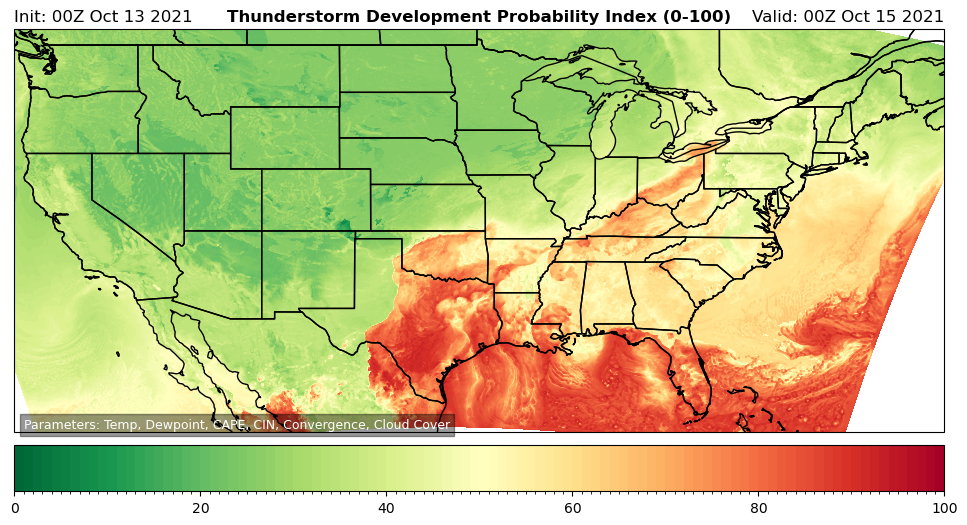

In [30]:
import numpy as np
import matplotlib.colors as mcolors

fig, ax = conus_map()

# Define exact boundaries for 0–100
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

# Plot with fixed boundaries
c = ax.contourf(
    fcst['longitude'], 
    fcst['latitude'], 
    index,
    cmap='RdYlGn_r',
    levels=bounds,      # <-- exact levels
    norm=norm,          # <-- prevents auto-expansion
    shading='auto'
)

# Add colorbar with ticks exactly at the ends
cb = plt.colorbar(
    c,
    ax=ax,
    orientation='horizontal',
    pad=0.02,
    ticks=[0, 20, 40, 60, 80, 100]   # 0 at left edge, 100 at right edge
)

# Titles
plt.title("Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

# Attribution text
plt.text(
    0.01, 0.01,
    "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
    transform=ax.transAxes,
    fontsize=9,
    color='white',
    bbox=dict(facecolor='black', alpha=0.4, pad=3)
)

plt.show()


# Auto Generation Plots: 

In [32]:
# Imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units

In [33]:
# Load Data
ds = xr.open_dataset('MergedIncident')
ds = ds.sortby('valid_time')

ds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-01T15:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [34]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.calc import lat_lon_grid_deltas

# Ensure output directory exists
outdir = "threat_plots"
os.makedirs(outdir, exist_ok=True)

# Conus Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

# Threat index function
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))
    cape_index = 100 * (1 - np.exp(-cape / 1000))
    cin_index = 100 * np.exp(-np.abs(cin) / 100)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    index = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)
    return index

# Loop over all times in the dataset
for i in range(len(ds.valid_time)):

    fcst = ds.isel(valid_time=i)

    # Convert times
    init_time = pd.to_datetime(ds.time.values)
    valid_time = pd.to_datetime(fcst.valid_time.values)
    init_str = init_time.strftime('%HZ %b %d %Y')
    valid_str = valid_time.strftime('%HZ %b %d %Y')

    # Compute fields
    temp_f = (fcst['t2m'] - 273.15) * 9/5 + 32
    dewpt_f = (fcst['d2m'] - 273.15) * 9/5 + 32
    cape = fcst['cape']
    cin = fcst['cin']
    cloud = fcst['tcc'] * 100

    dx, dy = lat_lon_grid_deltas(fcst['longitude'].values, fcst['latitude'].values)
    convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)

    # Compute threat index
    index = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

    # Plotted conus map
    fig, ax = conus_map()

    bounds = np.linspace(0, 100, 101)
    norm = mcolors.BoundaryNorm(bounds, ncolors=256)

    c = ax.contourf(
        fcst['longitude'],
        fcst['latitude'],
        index,
        cmap='RdYlGn_r',
        levels=bounds,
        norm=norm,
        shading='auto'
    )

    cb = plt.colorbar(
        c,
        ax=ax,
        orientation='horizontal',
        pad=0.02,
        ticks=[0, 20, 40, 60, 80, 100]
    )

    plt.title("Thunderstorm Development Probability Index (0–100)", loc='center', fontweight='bold')
    plt.title(f"Init: {init_str}", loc='left')
    plt.title(f"Valid: {valid_str}", loc='right')

    plt.text(
        0.01, 0.01,
        "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='black', alpha=0.4, pad=3)
    )

    # Save files as named pngs
    fname = f"threat_{i:03d}.png"
    plt.savefig(os.path.join(outdir, fname), dpi=150, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved {fname}")


/tmp/ipykernel_572342/3030477981.py:57: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_000.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_001.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


...

Saved threat_046.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_047.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_048.png
